In [1]:
import gdown
import zipfile
import os

# Google Drive file ID from the link
file_id = '1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.zip'

# Download the file
gdown.download(url, output, quiet=False)

# Extract the zip file
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('dataset_content')

print("Extraction complete.")

Downloading...
From (original): https://drive.google.com/uc?id=1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw
From (redirected): https://drive.google.com/uc?id=1uJmDZw649XS-r-dYs9WD-OPwF_TIroVw&confirm=t&uuid=072b6d9b-69c1-4db6-9959-b1328c910cb6
To: /kaggle/working/dataset.zip
100%|██████████| 533M/533M [00:03<00:00, 156MB/s]


Extraction complete.


In [2]:
!pip install timm einops scikit-image

import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
class SRDataset(Dataset):
    def __init__(self, root_dir):
        self.lr_dir = os.path.join(root_dir, "LR")
        self.hr_dir = os.path.join(root_dir, "HR")
        self.files = sorted(os.listdir(self.lr_dir))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]

        lr = np.load(os.path.join(self.lr_dir, file_name))
        hr = np.load(os.path.join(self.hr_dir, file_name))

        # Convert to tensor (NO normalization needed)
        lr = torch.tensor(lr, dtype=torch.float32)
        hr = torch.tensor(hr, dtype=torch.float32)

        # Ensure channel dimension
        if len(lr.shape) == 2:
            lr = lr.unsqueeze(0)
        if len(hr.shape) == 2:
            hr = hr.unsqueeze(0)

        # Center Crop to make divisible by 8 for SwinIR
        # This keeps the lens in the center and removes only the background edges
        lr = F.center_crop(lr, (64, 64))
        hr = F.center_crop(hr, (128, 128))

        return lr, hr

Total number of samples (LR/HR pairs) in dataset: 10000
Shape of LR image in first sample: torch.Size([1, 64, 64])
Shape of HR image in first sample: torch.Size([1, 128, 128])
torch.Size([1, 64, 64])
tensor(0.0045) tensor(0.9734)
torch.Size([1, 128, 128])
tensor(0.) tensor(1.)


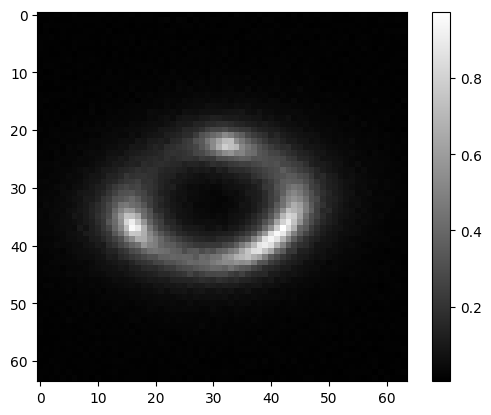

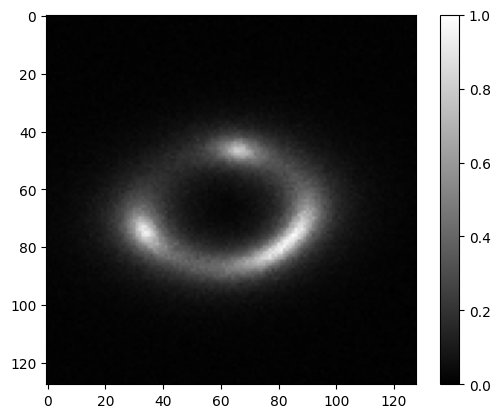

In [4]:
dataset = SRDataset("/kaggle/working/dataset_content/Dataset")

print(f"Total number of samples (LR/HR pairs) in dataset: {len(dataset)}")

lr, hr = dataset[0]

print("Shape of LR image in first sample:", lr.shape)
print("Shape of HR image in first sample:", hr.shape)
print(lr.shape)
print(lr.min(), lr.max())
print(hr.shape)
print(hr.min(), hr.max())

# Show image
plt.imshow(lr.squeeze(), cmap='gray')
plt.colorbar()
plt.show()
# Show image
plt.imshow(hr.squeeze(), cmap='gray')
plt.colorbar()
plt.show()

In [5]:
from torch.utils.data import random_split, DataLoader

# Load full dataset (correct path)
full_dataset = SRDataset("/kaggle/working/dataset_content/Dataset")

# 90-10 split
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# DataLoaders
# Further reduce batch_size to prevent CUDA out of memory errors
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True) # Reduced from 8 to 4
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)   # Reduced from 8 to 4

# Check
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 9000
Val size: 1000


In [6]:
!pip install transformers


In [7]:
import torch
from transformers import Swin2SRForImageSuperResolution, Swin2SRConfig

# 1. Create a configuration that matches your specific task
# We use Swin2SR because it is the standard for Transformers SR on Hugging Face
config = Swin2SRConfig(
    upscale=2,
    in_chans=1,                # Input: Grayscale [1, 64, 64]
    num_channels=1,            # Output: Grayscale [1, 128, 128]
    img_size=64,               # Matches your CenterCrop
    window_size=8,             # Standard Swin window
    depths=[4, 4, 4, 4],       # 4 stages for deep feature extraction
    embed_dim=60,              # Fits safely in T4 VRAM
    num_heads=[6, 6, 6, 6],    # Attention heads (must divide embed_dim)
    mlp_ratio=2,               # Standard feed-forward ratio
    upsampler='pixelshuffle'   # Best for sharp Einstein Rings
)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = Swin2SRForImageSuperResolution(config).to(device)


# 2. Initialize the model with this configuration


model = Swin2SRForImageSuperResolution(config)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)



print("Actual Transformer Model Initialized Successfully from Hugging Face!")


Using 2 GPUs!
Actual Transformer Model Initialized Successfully from Hugging Face!


In [8]:
import torch.optim as optim

# 1. Use AdamW for Transformers
optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,              # Slightly higher initial LR for AdamW
    weight_decay=1e-4,    # Helps prevent overfitting to simulated noise
    betas=(0.9, 0.999)
)

# 2. Match T_max to your total training epochs (e.g., 50)
num_epochs = 20
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs,
    eta_min=1e-6          # Don't let the LR hit absolute zero
)

# 3. L1 Loss is the gold standard for Super-Resolution
criterion = torch.nn.L1Loss()


In [9]:
def train(model, train_loader, val_loader, optimizer, scheduler, criterion, device, epochs):
    model.to(device)
    history = {"train_loss": [], "val_ssim": [], "val_psnr": []}
    best_ssim = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for lr_img, hr_img in train_loader:
            lr_img, hr_img = lr_img.to(device), hr_img.to(device)

            optimizer.zero_grad()
            output = model(lr_img)
            sr_img = output.reconstruction 

            loss = criterion(sr_img, hr_img)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += loss.item()

        scheduler.step()
        epoch_loss = running_loss / len(train_loader)
        history["train_loss"].append(epoch_loss)

        # Validation for Performance Tracking
        model.eval()
        ssim_total = 0
        psnr_total = 0
        with torch.no_grad():
            for lr_val, hr_val in val_loader:
                lr_val, hr_val = lr_val.to(device), hr_val.to(device)
                sr_val = model(lr_val).reconstruction
                sr_val = torch.clamp(sr_val, 0.0, 1.0)

                sr_np = sr_val.cpu().numpy()
                hr_np = hr_val.cpu().numpy()
                for i in range(len(sr_np)):
                    pred = np.squeeze(sr_np[i])
                    gt = np.squeeze(hr_np[i])
                    ssim_total += ssim(gt, pred, data_range=1.0)
                    psnr_total += psnr(gt, pred, data_range=1.0)
        
        avg_ssim = ssim_total / len(val_loader.dataset)
        avg_psnr = psnr_total / len(val_loader.dataset)
        history["val_ssim"].append(avg_ssim)
        history["val_psnr"].append(avg_psnr)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss:.6f}, SSIM: {avg_ssim:.4f}, PSNR: {avg_psnr:.4f} dB")

        # Save Best Model Logic
        if avg_ssim > best_ssim:
            best_ssim = avg_ssim
            torch.save(model.state_dict(), "best_model.pth")
            print(f"--> Saved Best Model with SSIM: {avg_ssim:.4f}")

    return history


Epoch [1/20] - Loss: 0.008801, SSIM: 0.9710, PSNR: 39.4591 dB
--> Saved Best Model with SSIM: 0.9710
Epoch [2/20] - Loss: 0.006072, SSIM: 0.9738, PSNR: 40.2921 dB
--> Saved Best Model with SSIM: 0.9738
Epoch [3/20] - Loss: 0.005895, SSIM: 0.9744, PSNR: 40.9941 dB
--> Saved Best Model with SSIM: 0.9744
Epoch [4/20] - Loss: 0.005849, SSIM: 0.9741, PSNR: 41.0327 dB
Epoch [5/20] - Loss: 0.005813, SSIM: 0.9745, PSNR: 40.9135 dB
--> Saved Best Model with SSIM: 0.9745
Epoch [6/20] - Loss: 0.005796, SSIM: 0.9745, PSNR: 40.7485 dB
Epoch [7/20] - Loss: 0.005722, SSIM: 0.9748, PSNR: 41.1649 dB
--> Saved Best Model with SSIM: 0.9748
Epoch [8/20] - Loss: 0.005710, SSIM: 0.9749, PSNR: 41.0627 dB
--> Saved Best Model with SSIM: 0.9749
Epoch [9/20] - Loss: 0.005695, SSIM: 0.9710, PSNR: 40.8271 dB
Epoch [10/20] - Loss: 0.005674, SSIM: 0.9749, PSNR: 41.1728 dB
--> Saved Best Model with SSIM: 0.9749
Epoch [11/20] - Loss: 0.005659, SSIM: 0.9750, PSNR: 41.2143 dB
--> Saved Best Model with SSIM: 0.9750
Epoc

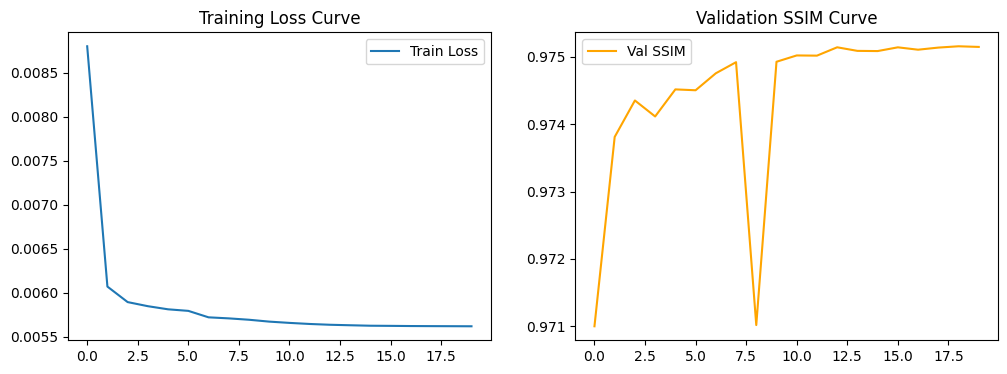

In [10]:
# 4. CALL THE TRAINING LOOP WITH HISTORY TRACKING
history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    device=device,
    epochs=num_epochs
)

# Plot Learning Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history['val_ssim'], label='Val SSIM', color='orange')
plt.title('Validation SSIM Curve')
plt.legend()
plt.show()

In [11]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import numpy as np
import torch

model.eval()

mse_total = 0
ssim_total = 0
psnr_total = 0
n = len(val_loader.dataset)

with torch.no_grad():
    for lr_img, hr_img in val_loader:
        lr_img, hr_img = lr_img.to(device), hr_img.to(device)

        # 1. Forward pass
        output = model(lr_img).reconstruction

        # 2. Clamp output to [0, 1] range (Essential for SR models)
        # Sometimes models predict slightly outside range, which breaks SSIM/PSNR
        output = torch.clamp(output, 0.0, 1.0)

        # 3. Move to CPU and NumPy once per batch for speed
        output_np = output.cpu().numpy()
        hr_np = hr_img.cpu().numpy()

        for i in range(len(output_np)):
            # Squeeze to [H, W] for skimage metrics
            pred = np.squeeze(output_np[i])
            gt = np.squeeze(hr_np[i])

            # MSE Calculation
            mse_val = np.mean((pred - gt) ** 2)
            mse_total += mse_val

            # SSIM Calculation (Ensuring 1.0 data_range)
            ssim_val = ssim(gt, pred, data_range=1.0)
            ssim_total += ssim_val

            # PSNR Calculation (Ensuring 1.0 data_range)
            psnr_val = psnr(gt, pred, data_range=1.0)
            psnr_total += psnr_val

print(f"Validation Results on {n} samples:")
print(f"MSE:  {mse_total/n:.8f}")
print(f"SSIM: {ssim_total/n:.4f}")
print(f"PSNR: {psnr_total/n:.4f} dB")


Validation Results on 1000 samples:
MSE:  0.00007577
SSIM: 0.9751
PSNR: 41.2477 dB


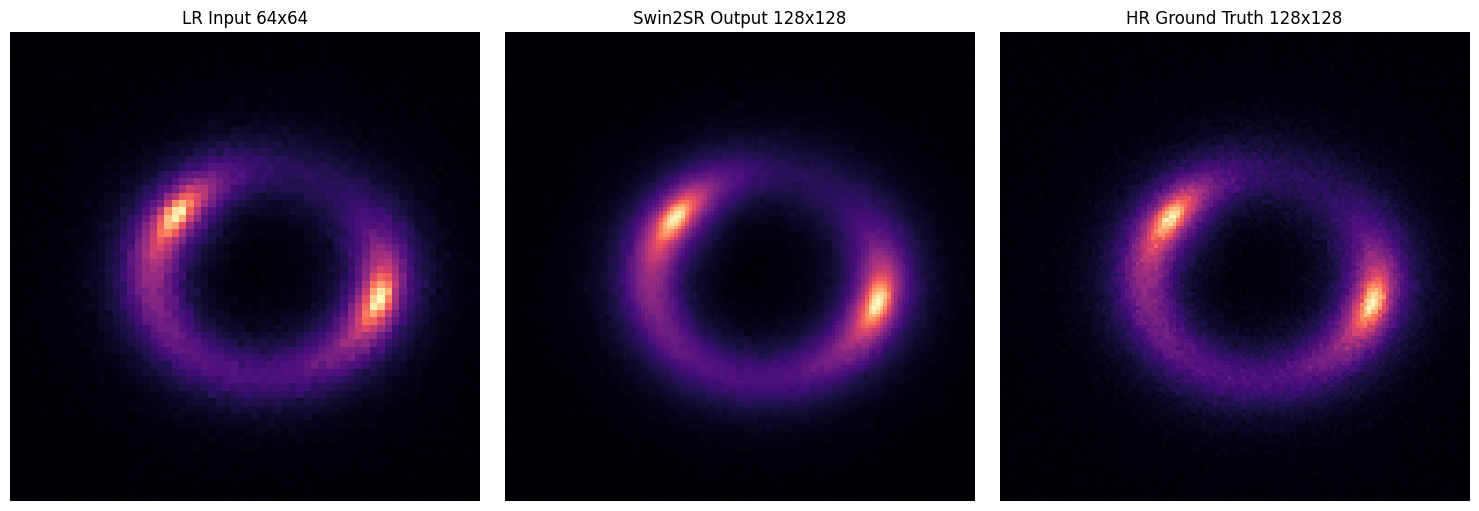

In [12]:
import matplotlib.pyplot as plt
import torch
import random
import numpy as np

# Deterministic Evaluation: Set seeds for consistent visualization
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# 1. Get a single sample and move to GPU
lr, hr = val_dataset[10] # Using val_dataset (fixed name)
lr_input = lr.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    # 2. Forward pass and clamp to [0, 1] range
    output = model(lr_input)
    sr = torch.clamp(output.reconstruction, 0.0, 1.0).cpu()

# 3. Visualization
plt.figure(figsize=(15, 5))

# Plot LR (Low Resolution)
plt.subplot(1, 3, 1)
plt.imshow(lr[0], cmap='magma') 
plt.title(f"LR Input {lr.shape[1]}x{lr.shape[2]}")
plt.axis('off')

# Plot SR (Model Output)
plt.subplot(1, 3, 2)
plt.imshow(sr[0][0], cmap='magma')
plt.title(f"Swin2SR Output {sr.shape[2]}x{sr.shape[3]}")
plt.axis('off')

# Plot HR (Ground Truth)
plt.subplot(1, 3, 3)
plt.imshow(hr[0], cmap='magma')
plt.title(f"HR Ground Truth {hr.shape[1]}x{hr.shape[2]}")
plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
torch.save(model.state_dict(), "model.pth")